 REPORT COMPLETO DE EVALUACIÓN

--- METRICAS DE CLASIFICACIÓN (UMBRAL 50%) ---
Accuracy (Exactitud Global):  0.6110
Precision (Valor Predictivo): 0.7410
Recall / TPR (Sensibilidad):  0.7400
Especificidad / TNR:         0.2240
FPR (Tasa Falsos Positivos): 0.7760
FNR (Tasa Falsos Negativos): 0.2600
F1-Score (Balance P/R):       0.7405

--- CALIBRACIÓN Y ERRORES DE PREDICCIÓN ---
MAE (Error Absoluto Medio):        0.3976 (39.76%)
RMSE (Raíz Error Cuadrático):     0.5595 (55.95%)


C:\Users\Windows\AppData\Local\Temp\ipykernel_7512\4089264291.py:120: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Windows\AppData\Local\Temp\ipykernel_7512\4089264291.py:138: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


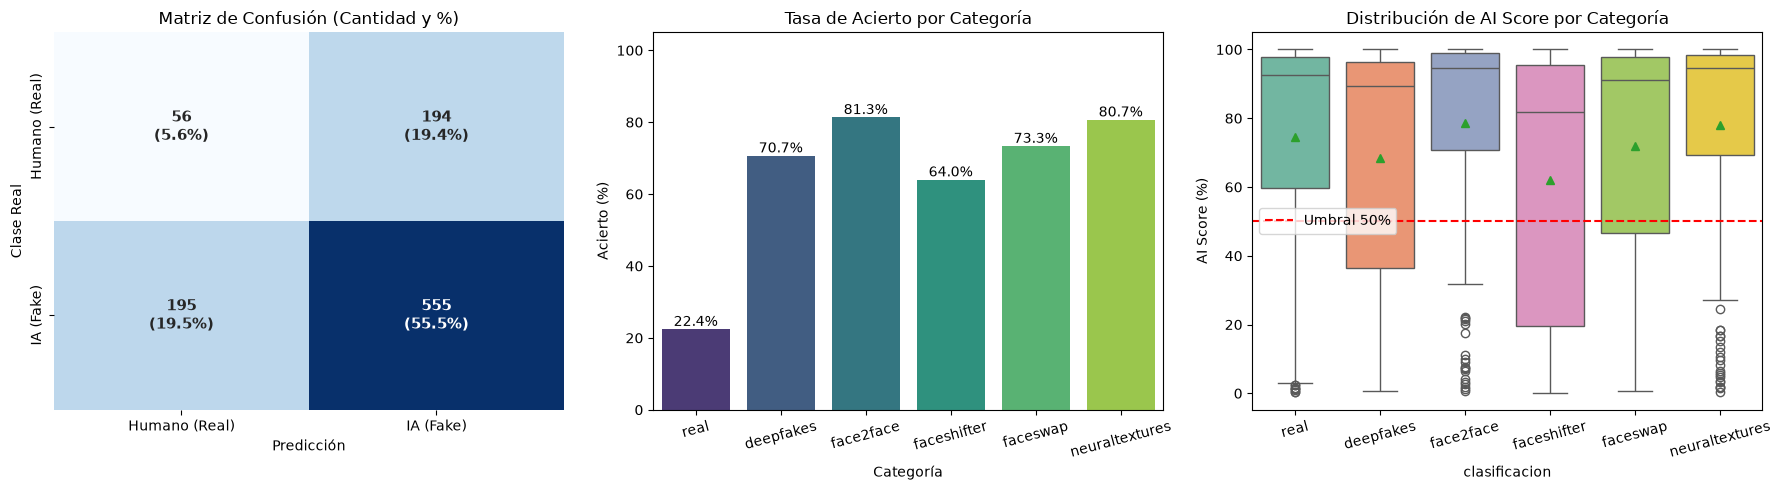

In [16]:
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    recall_score
)

# 1. Cargar el JSON procesado
PATH_JSON = r"D:\OneDrive - UNIR\Master\99.TFM\DataSets\Resultados_Analisis\DeepFakeDetector_clean.json"

with open(PATH_JSON, "r", encoding="utf-8") as f:
    data = json.load(f)

df = pd.DataFrame.from_dict(data, orient="index")

# 2. Preparación de variables binarias y continuas
df["y_true"] = df["clasificacion"].apply(lambda x: 0 if x == "real" else 1)
df["y_score"] = df["AI Score"] / 100.0
df["y_pred"] = (df["y_score"] >= 0.5).astype(int)

scores_real = df[df["y_true"] == 0]["y_score"]
scores_fake = df[df["y_true"] == 1]["y_score"]

# 3. Métricas de Clasificación Binaria
cm = confusion_matrix(df["y_true"], df["y_pred"])
tn, fp, fn, tp = cm.ravel()

accuracy = accuracy_score(df["y_true"], df["y_pred"])
precision = precision_score(df["y_true"], df["y_pred"])
recall = recall_score(df["y_true"], df["y_pred"])
specificity = tn / (tn + fp)
fpr = fp / (fp + tn)
fnr = fn / (fn + tp)
f1 = f1_score(df["y_true"], df["y_pred"])


# ECE (Expected Calibration Error)
def calculate_ece(y_true, y_prob, n_bins=10):
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        bin_lower, bin_upper = bin_boundaries[i], bin_boundaries[i + 1]
        in_bin = (y_prob >= bin_lower) & (y_prob < bin_upper)
        prop_in_bin = np.mean(in_bin)
        if prop_in_bin > 0:
            accuracy_in_bin = np.mean(y_true[in_bin])
            avg_confidence_in_bin = np.mean(y_prob[in_bin])
            ece += np.abs(accuracy_in_bin - avg_confidence_in_bin) * prop_in_bin
    return ece


# Errores de regresión/calibración
mae = mean_absolute_error(df["y_true"], df["y_score"])
rmse = np.sqrt(mean_squared_error(df["y_true"], df["y_score"]))

# 5. Impresión Consolidada de Resultados
print("=" * 65)
print(f" REPORT COMPLETO DE EVALUACIÓN")
print("=" * 65)

print("\n--- METRICAS DE CLASIFICACIÓN (UMBRAL 50%) ---")
print(f"Accuracy (Exactitud Global):  {accuracy:.4f}")
print(f"Precision (Valor Predictivo): {precision:.4f}")
print(f"Recall / TPR (Sensibilidad):  {recall:.4f}")
print(f"Especificidad / TNR:         {specificity:.4f}")
print(f"FPR (Tasa Falsos Positivos): {fpr:.4f}")
print(f"FNR (Tasa Falsos Negativos): {fnr:.4f}")
print(f"F1-Score (Balance P/R):       {f1:.4f}")


print("\n--- CALIBRACIÓN Y ERRORES DE PREDICCIÓN ---")
print(f"MAE (Error Absoluto Medio):        {mae:.4f} ({mae*100:.2f}%)")
print(f"RMSE (Raíz Error Cuadrático):     {rmse:.4f} ({rmse*100:.2f}%)")

# 6. Panel Visual Ajustado (3 Gráficas Seleccionadas)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Matriz de Confusión (Mostrando Absolutos y Porcentajes %)
total_muestras = len(df)
cm_perc = cm / total_muestras * 100

# Construir etiquetas internas con recuento y porcentaje
labels = [
    f"{count}\n({perc:.1f}%)"
    for count, perc in zip(cm.flatten(), cm_perc.flatten())
]
labels = np.array(labels).reshape(2, 2)

sns.heatmap(
    cm,
    annot=labels,
    fmt="",
    cmap="Blues",
    cbar=False,
    xticklabels=["Humano (Real)", "IA (Fake)"],
    yticklabels=["Humano (Real)", "IA (Fake)"],
    ax=axes[0],
    annot_kws={"size": 11, "weight": "bold"},
)
axes[0].set_title("Matriz de Confusión (Cantidad y %)")
axes[0].set_xlabel("Predicción")
axes[0].set_ylabel("Clase Real")

# 2. Tasa de Acierto por Categoría
rendimiento_cat = []
for tipo in df["clasificacion"].unique():
    sub = df[df["clasificacion"] == tipo]
    acierto = (sub["y_pred"] == (0 if tipo == "real" else 1)).mean() * 100
    rendimiento_cat.append({"Categoría": tipo, "Acierto (%)": acierto})

df_rend = pd.DataFrame(rendimiento_cat)
sns.barplot(
    data=df_rend, x="Categoría", y="Acierto (%)", palette="viridis", ax=axes[1]
)
axes[1].set_title("Tasa de Acierto por Categoría")
axes[1].set_ylim(0, 105)
axes[1].tick_params(axis="x", rotation=15)

for p in axes[1].patches:
    axes[1].annotate(
        f"{p.get_height():.1f}%",
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="center",
        xytext=(0, 5),
        textcoords="offset points",
    )

# 3. Boxplot por Categoría (Distribución de AI Score)
sns.boxplot(
    data=df,
    x="clasificacion",
    y="AI Score",
    palette="Set2",
    ax=axes[2],
    showmeans=True,
)
axes[2].axhline(50, color="red", linestyle="--", label="Umbral 50%")
axes[2].set_title("Distribución de AI Score por Categoría")
axes[2].set_ylabel("AI Score (%)")
axes[2].tick_params(axis="x", rotation=15)
axes[2].legend()

plt.tight_layout()
plt.show()

 REPORT COMPLETO DE EVALUACIÓN

--- METRICAS DE CLASIFICACIÓN (UMBRAL 50%) ---
Accuracy (Exactitud Global):  0.2700
Precision (Valor Predictivo): 0.7500
Recall / TPR (Sensibilidad):  0.0400
Especificidad / TNR:         0.9600
FPR (Tasa Falsos Positivos): 0.0400
FNR (Tasa Falsos Negativos): 0.9600
F1-Score (Balance P/R):       0.0759

--- CALIBRACIÓN Y ERRORES DE PREDICCIÓN ---
MAE (Error Absoluto Medio):        0.7119 (71.19%)
RMSE (Raíz Error Cuadrático):     0.8200 (82.00%)


C:\Users\Windows\AppData\Local\Temp\ipykernel_7512\3214739823.py:123: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Windows\AppData\Local\Temp\ipykernel_7512\3214739823.py:141: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


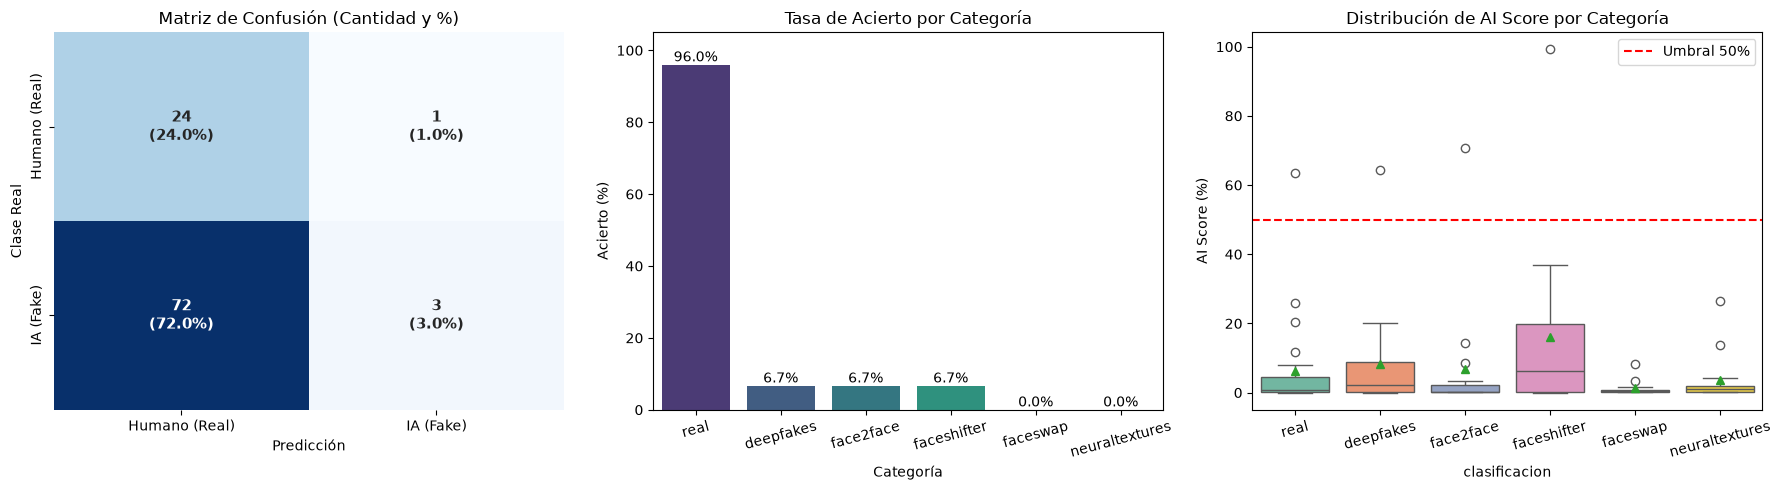

In [ ]:
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    recall_score
)

# 1. Cargar el JSON procesado
PATH_JSON = r"D:\OneDrive - UNIR\Master\99.TFM\DataSets\Resultados_Analisis\Hive_clean.json"

with open(PATH_JSON, "r", encoding="utf-8") as f:
    data = json.load(f)

df = pd.DataFrame.from_dict(data, orient="index")

# 2. Preparación de variables binarias y continuas
df["y_true"] = df["clasificacion"].apply(lambda x: 0 if x == "real" else 1)
df["y_score"] = df["AI Score"] / 100.0
df["y_pred"] = (df["y_score"] >= 0.5).astype(int)

scores_real = df[df["y_true"] == 0]["y_score"]
scores_fake = df[df["y_true"] == 1]["y_score"]

# 3. Métricas de Clasificación Binaria
cm = confusion_matrix(df["y_true"], df["y_pred"])
tn, fp, fn, tp = cm.ravel()

accuracy = accuracy_score(df["y_true"], df["y_pred"])
precision = precision_score(df["y_true"], df["y_pred"])
recall = recall_score(df["y_true"], df["y_pred"])
specificity = tn / (tn + fp)
fpr = fp / (fp + tn)
fnr = fn / (fn + tp)
f1 = f1_score(df["y_true"], df["y_pred"])


# ECE (Expected Calibration Error)
def calculate_ece(y_true, y_prob, n_bins=10):
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        bin_lower, bin_upper = bin_boundaries[i], bin_boundaries[i + 1]
        in_bin = (y_prob >= bin_lower) & (y_prob < bin_upper)
        prop_in_bin = np.mean(in_bin)
        if prop_in_bin > 0:
            accuracy_in_bin = np.mean(y_true[in_bin])
            avg_confidence_in_bin = np.mean(y_prob[in_bin])
            ece += np.abs(accuracy_in_bin - avg_confidence_in_bin) * prop_in_bin
    return ece


# Errores de regresión/calibración
mae = mean_absolute_error(df["y_true"], df["y_score"])
rmse = np.sqrt(mean_squared_error(df["y_true"], df["y_score"]))

# 5. Impresión Consolidada de Resultados
print("=" * 65)
print(f" REPORT COMPLETO DE EVALUACIÓN")
print("=" * 65)

print("\n--- METRICAS DE CLASIFICACIÓN (UMBRAL 50%) ---")
print(f"Accuracy (Exactitud Global):  {accuracy:.4f}")
print(f"Precision (Valor Predictivo): {precision:.4f}")
print(f"Recall / TPR (Sensibilidad):  {recall:.4f}")
print(f"Especificidad / TNR:         {specificity:.4f}")
print(f"FPR (Tasa Falsos Positivos): {fpr:.4f}")
print(f"FNR (Tasa Falsos Negativos): {fnr:.4f}")
print(f"F1-Score (Balance P/R):       {f1:.4f}")


print("\n--- CALIBRACIÓN Y ERRORES DE PREDICCIÓN ---")
print(f"MAE (Error Absoluto Medio):        {mae:.4f} ({mae*100:.2f}%)")
print(f"RMSE (Raíz Error Cuadrático):     {rmse:.4f} ({rmse*100:.2f}%)")

# 6. Panel Visual Ajustado (3 Gráficas Seleccionadas)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Matriz de Confusión (Mostrando Absolutos y Porcentajes %)
total_muestras = len(df)
cm_perc = cm / total_muestras * 100

# Construir etiquetas internas con recuento y porcentaje
labels = [
    f"{count}\n({perc:.1f}%)"
    for count, perc in zip(cm.flatten(), cm_perc.flatten())
]
labels = np.array(labels).reshape(2, 2)

sns.heatmap(
    cm,
    annot=labels,
    fmt="",
    cmap="Blues",
    cbar=False,
    xticklabels=["Humano (Real)", "IA (Fake)"],
    yticklabels=["Humano (Real)", "IA (Fake)"],
    ax=axes[0],
    annot_kws={"size": 11, "weight": "bold"},
)
axes[0].set_title("Matriz de Confusión (Cantidad y %)")
axes[0].set_xlabel("Predicción")
axes[0].set_ylabel("Clase Real")

# 2. Tasa de Acierto por Categoría
rendimiento_cat = []
for tipo in df["clasificacion"].unique():
    sub = df[df["clasificacion"] == tipo]
    acierto = (sub["y_pred"] == (0 if tipo == "real" else 1)).mean() * 100
    rendimiento_cat.append({"Categoría": tipo, "Acierto (%)": acierto})

df_rend = pd.DataFrame(rendimiento_cat)
sns.barplot(
    data=df_rend, x="Categoría", y="Acierto (%)", palette="viridis", ax=axes[1]
)
axes[1].set_title("Tasa de Acierto por Categoría")
axes[1].set_ylim(0, 105)
axes[1].tick_params(axis="x", rotation=15)

for p in axes[1].patches:
    axes[1].annotate(
        f"{p.get_height():.1f}%",
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="center",
        xytext=(0, 5),
        textcoords="offset points",
    )

# 3. Boxplot por Categoría (Distribución de AI Score)
sns.boxplot(
    data=df,
    x="clasificacion",
    y="AI Score",
    palette="Set2",
    ax=axes[2],
    showmeans=True,
)
axes[2].axhline(50, color="red", linestyle="--", label="Umbral 50%")
axes[2].set_title("Distribución de AI Score por Categoría")
axes[2].set_ylabel("AI Score (%)")
axes[2].tick_params(axis="x", rotation=15)
axes[2].legend()

plt.tight_layout()
plt.show()

 REPORT COMPLETO DE EVALUACIÓN

--- METRICAS DE CLASIFICACIÓN (UMBRAL 50%) ---
Accuracy (Exactitud Global):  0.4170
Precision (Valor Predictivo): 0.9941
Recall / TPR (Sensibilidad):  0.2240
Especificidad / TNR:         0.9960
FPR (Tasa Falsos Positivos): 0.0040
FNR (Tasa Falsos Negativos): 0.7760
F1-Score (Balance P/R):       0.3656

--- CALIBRACIÓN Y ERRORES DE PREDICCIÓN ---
MAE (Error Absoluto Medio):        0.5835 (58.35%)
RMSE (Raíz Error Cuadrático):     0.7371 (73.71%)


C:\Users\Windows\AppData\Local\Temp\ipykernel_7512\2544542931.py:123: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Windows\AppData\Local\Temp\ipykernel_7512\2544542931.py:141: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


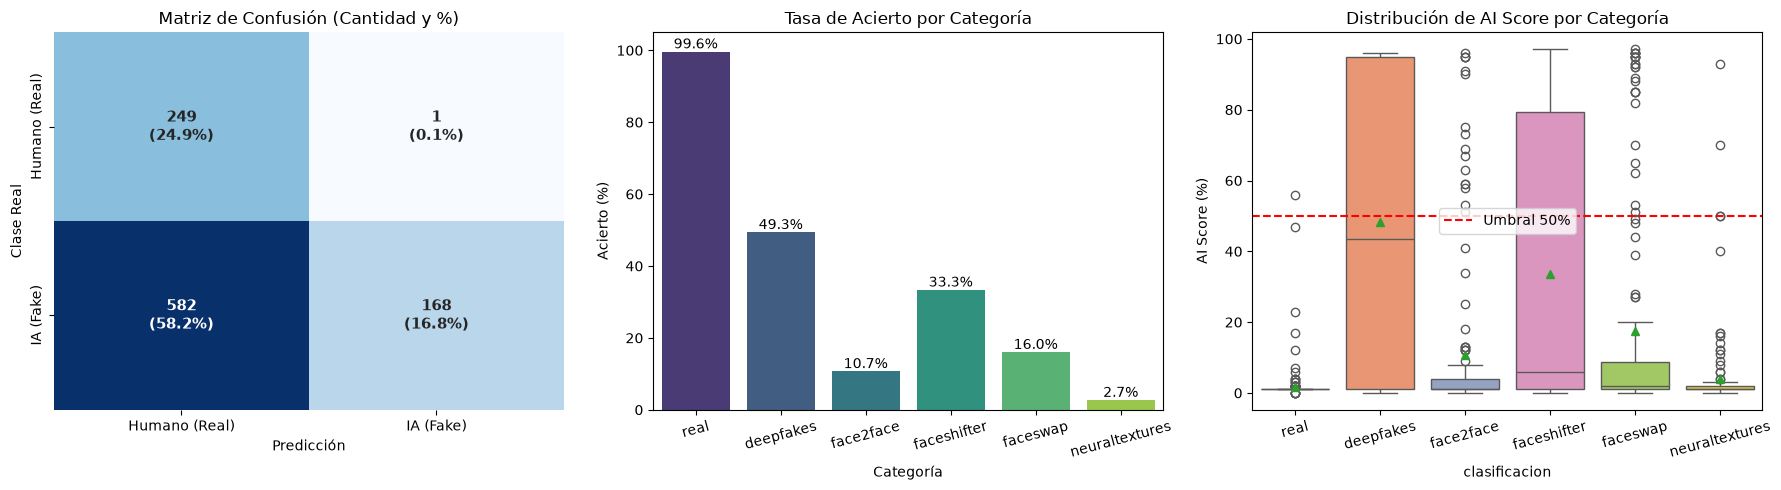

In [ ]:
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    recall_score
)

# 1. Cargar el JSON procesado
PATH_JSON = r"D:\OneDrive - UNIR\Master\99.TFM\DataSets\Resultados_Analisis\Sightengine_clean.json"

with open(PATH_JSON, "r", encoding="utf-8") as f:
    data = json.load(f)

df = pd.DataFrame.from_dict(data, orient="index")

# 2. Preparación de variables binarias y continuas
df["y_true"] = df["clasificacion"].apply(lambda x: 0 if x == "real" else 1)
df["y_score"] = df["AI Score"] / 100.0
df["y_pred"] = (df["y_score"] >= 0.5).astype(int)

scores_real = df[df["y_true"] == 0]["y_score"]
scores_fake = df[df["y_true"] == 1]["y_score"]

# 3. Métricas de Clasificación Binaria
cm = confusion_matrix(df["y_true"], df["y_pred"])
tn, fp, fn, tp = cm.ravel()

accuracy = accuracy_score(df["y_true"], df["y_pred"])
precision = precision_score(df["y_true"], df["y_pred"])
recall = recall_score(df["y_true"], df["y_pred"])
specificity = tn / (tn + fp)
fpr = fp / (fp + tn)
fnr = fn / (fn + tp)
f1 = f1_score(df["y_true"], df["y_pred"])


# ECE (Expected Calibration Error)
def calculate_ece(y_true, y_prob, n_bins=10):
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        bin_lower, bin_upper = bin_boundaries[i], bin_boundaries[i + 1]
        in_bin = (y_prob >= bin_lower) & (y_prob < bin_upper)
        prop_in_bin = np.mean(in_bin)
        if prop_in_bin > 0:
            accuracy_in_bin = np.mean(y_true[in_bin])
            avg_confidence_in_bin = np.mean(y_prob[in_bin])
            ece += np.abs(accuracy_in_bin - avg_confidence_in_bin) * prop_in_bin
    return ece


# Errores de regresión/calibración
mae = mean_absolute_error(df["y_true"], df["y_score"])
rmse = np.sqrt(mean_squared_error(df["y_true"], df["y_score"]))

# 5. Impresión Consolidada de Resultados
print("=" * 65)
print(f" REPORT COMPLETO DE EVALUACIÓN")
print("=" * 65)

print("\n--- METRICAS DE CLASIFICACIÓN (UMBRAL 50%) ---")
print(f"Accuracy (Exactitud Global):  {accuracy:.4f}")
print(f"Precision (Valor Predictivo): {precision:.4f}")
print(f"Recall / TPR (Sensibilidad):  {recall:.4f}")
print(f"Especificidad / TNR:         {specificity:.4f}")
print(f"FPR (Tasa Falsos Positivos): {fpr:.4f}")
print(f"FNR (Tasa Falsos Negativos): {fnr:.4f}")
print(f"F1-Score (Balance P/R):       {f1:.4f}")


print("\n--- CALIBRACIÓN Y ERRORES DE PREDICCIÓN ---")
print(f"MAE (Error Absoluto Medio):        {mae:.4f} ({mae*100:.2f}%)")
print(f"RMSE (Raíz Error Cuadrático):     {rmse:.4f} ({rmse*100:.2f}%)")

# 6. Panel Visual Ajustado (3 Gráficas Seleccionadas)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Matriz de Confusión (Mostrando Absolutos y Porcentajes %)
total_muestras = len(df)
cm_perc = cm / total_muestras * 100

# Construir etiquetas internas con recuento y porcentaje
labels = [
    f"{count}\n({perc:.1f}%)"
    for count, perc in zip(cm.flatten(), cm_perc.flatten())
]
labels = np.array(labels).reshape(2, 2)

sns.heatmap(
    cm,
    annot=labels,
    fmt="",
    cmap="Blues",
    cbar=False,
    xticklabels=["Humano (Real)", "IA (Fake)"],
    yticklabels=["Humano (Real)", "IA (Fake)"],
    ax=axes[0],
    annot_kws={"size": 11, "weight": "bold"},
)
axes[0].set_title("Matriz de Confusión (Cantidad y %)")
axes[0].set_xlabel("Predicción")
axes[0].set_ylabel("Clase Real")

# 2. Tasa de Acierto por Categoría
rendimiento_cat = []
for tipo in df["clasificacion"].unique():
    sub = df[df["clasificacion"] == tipo]
    acierto = (sub["y_pred"] == (0 if tipo == "real" else 1)).mean() * 100
    rendimiento_cat.append({"Categoría": tipo, "Acierto (%)": acierto})

df_rend = pd.DataFrame(rendimiento_cat)
sns.barplot(
    data=df_rend, x="Categoría", y="Acierto (%)", palette="viridis", ax=axes[1]
)
axes[1].set_title("Tasa de Acierto por Categoría")
axes[1].set_ylim(0, 105)
axes[1].tick_params(axis="x", rotation=15)

for p in axes[1].patches:
    axes[1].annotate(
        f"{p.get_height():.1f}%",
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="center",
        xytext=(0, 5),
        textcoords="offset points",
    )

# 3. Boxplot por Categoría (Distribución de AI Score)
sns.boxplot(
    data=df,
    x="clasificacion",
    y="AI Score",
    palette="Set2",
    ax=axes[2],
    showmeans=True,
)
axes[2].axhline(50, color="red", linestyle="--", label="Umbral 50%")
axes[2].set_title("Distribución de AI Score por Categoría")
axes[2].set_ylabel("AI Score (%)")
axes[2].tick_params(axis="x", rotation=15)
axes[2].legend()

plt.tight_layout()
plt.show()